# Linear Regression Example: Predicting Wide Receiver Catch Totals

The aim of this notebook is to show a real use of the linear regression class defined in our ML package.

Our analysis aims to use NFL wide receiver data to predict a player's total catches based on the types of targets (contested, catchable) and the average depth of target they receive.

In [21]:
# Import necessary libraries
import sys
import os

# Send Python to the project root so we can import our library
project_root = "/Users/maxbasurto/Documents/Rice Classes/CMOR 438/CMOR438-Project/src"
sys.path.append(project_root)

# Import our ML library and other necessary libraries
import rice_ml
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [22]:
# Import the dataset
data_path = "/Users/maxbasurto/Documents/Rice Classes/CMOR 438/CMOR438-Project/data/NFLReceivingStats.csv"
data = pd.read_csv(data_path)

Now that the necessary packages have been imported and the data has been loaded we can start the analysis. We begin by taking a quick look that the data and the columns we will be using.

In [23]:
# Select only the necessary columns and filter out rows where position is not WR
data = data[["Player Id", "Name", "POS", "REC", "CBL", "CTT", "ADOT"]]
data = data[data["POS"] == "WR"]

# Want players with at least 10 receptions to avoid outliers
data = data[data["REC"] >= 10]

# Drop null values
data = data.dropna()

# View the first few rows of the dataset
print(data.head())

   Player Id             Name POS  REC  CBL  CTT  ADOT
1       7808  DeAndre Hopkins  WR   24   26   19  14.5
4       7857     Keenan Allen  WR   85   96   27   8.7
6       8288     Adam Thielen  WR   22   27   10   8.7
8       8642       Mike Evans  WR   32   39   26  14.9
9       8655    Brandin Cooks  WR   29   32   17  17.0


In the above code, we filter out non-receivers from the data and select the columns previously defined as needed for the analysis. Furthermore, we eliminate any players with less than 10 catches to avoid putting noisy outliers into the model and drop missing values that could mess uup he model's training and prediction ability. 

From the minimal view of the table, we can see that we have a variety of receivers already. Brandin Cooks is much more of a deep threat as he has a high ADOT and low amount of receptions. Keenan is more of a slot, target hog WR with 85 catches and over 90 catchable targets.

Now we will use the linear regression function from our package to train the model in order to predict wide receiver reception totals.

In [24]:
# Use our standard scaler to normalize the features
scaler = rice_ml.StandardScaler()
data[["CBL", "CTT", "ADOT"]] = scaler.fit_transform(data[["CBL", "CTT", "ADOT"]])

# Use an 80-20 train-test split
train_data = data.sample(frac=0.8, random_state=42)
test_data = data.drop(train_data.index)

# Train the data using our library
model = rice_ml.LinearRegression()
model.train(train_data[["CBL", "CTT", "ADOT"]], train_data["REC"])

To most effectively train the model we use our preprocessing function StandardScaler to normalize our predictors. This prevents the matrix multiplication used to train a linear regression model from experiencing scale explosion.

Now that we have a trained model, we can make predictions and evaluate the effectiveness of our model.

In [25]:
# Make predictions on the test set
predictions = model.predict(test_data[["CBL", "CTT", "ADOT"]])

# Evaluate the model using measurements (MAE and R^2) from our library
mae = rice_ml.mean_absolute_error(test_data["REC"], predictions)
r2 = rice_ml.r_squared_score(test_data["REC"], predictions)

# Print the evaluation results
print(f"Mean Absolute Error: {mae}")
print(f"R^2 Score: {r2}")

Mean Absolute Error: 2.3408172595378507
R^2 Score: 0.9867570740554292


As expected, our model is very strong. It makes sense that a player with a high amount of targets (contested or catchable) will have a high amount of receptions. A lower average depth of target makes each catch more likely to occur as well. 

These three features explain 98.68% of the variance in total receptions over the course of the season. We also have a strong average error of just 2.3 receptions.

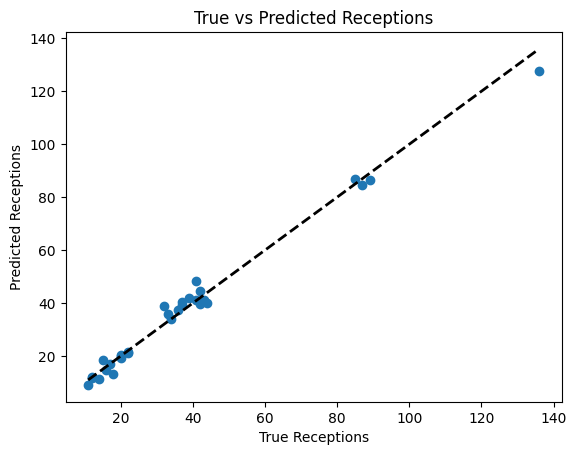

In [26]:
# Plot the true vs predicted values
plt.scatter(test_data["REC"], predictions)
plt.xlabel("True Receptions")
plt.ylabel("Predicted Receptions")
plt.title("True vs Predicted Receptions")
plt.plot([test_data["REC"].min(), test_data["REC"].max()], [test_data["REC"].min(), test_data["REC"].max()], 'k--', lw=2)
plt.show()

The graph above illustrates the relationship between the true values (x-axis) and our model's predicted values (y-axis) on the test data. Aligning with our validation metrics, the data points closely track the diagonal reference line. This is where the true value equals the predicted value, indicating high prediction accuracy.

Furthermore, the visualization reveals distinct clusters within our data. Despite these differing clusters, the model maintains consistent performance across all segments.

Because these three variables serve as strong predictors for receptions, we can conclude that once a wide receiver creates separation (or fails to), the responsibility of a completed pass falls almost entirely on the quarterback and the route design. The logic is straightforward: as catchable targets increase, receptions follow suit. Similarly, the closer a receiver is to the line of scrimmage, the higher the probability of a catch.

This provides a simpler lens for scouts to evaluate wide receiver skill sets. In the long run, our analysis suggests that a receiver's hands and contested-catch ability are insignificant to their overall production. Instead, a receiver's output hinges much more heavily on their ability to get open, simplifying the evaluation process for NFL scouts and coaches.

While a receiver’s size, strength, or catch radius might determine the outcome of a single play or series, these traits do not show long-term significance in determining total production. Ultimately, by leveraging the linear regression class in our machine learning package, we have extracted meaningful insights that challenge traditional scouting wisdom regarding the mechanics of the passing game.